In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
from nn_tools import Qfirst, Qfollowing, optimiers_list, one_batch_layers, EarlyStoppingList
import torch.nn as nn
from learning_tools import peak_one, algo_p, algo_e, update, perform_bids, assess_models
import seaborn as sns
import matplotlib.pyplot as plt
from torch import save
import tools

# Entraînement

In [2]:
def init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models = None, init_D = True, D = None):
    if init_D:
        D = [[torch.empty(0), torch.empty(0)] for _ in range(nb_layers)]  # Un dataset D par couche
    all_actions = list(range(36))  # 36 actions possibles
    if init_models:
        Q_models = [Qfirst() if i == 0 else Qfollowing() for i in range(nb_layers)]
    losses=[]
    val_losses = []
    if include_early_stopping:
        early_stop_list = EarlyStoppingList(min_es_list, patience_es_list)
    else:
        early_stop_list = None
    return D, all_actions, Q_models, losses, val_losses, early_stop_list


def augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions):
    bidding_history = np.zeros(36) # array de 5x36 pour enregistrer l'historique des enchères
    x1, x2, scores = peak_one(data)

    for j in range(nb_layers):
        C = np.zeros(36)  
        hand = x1 if (j+1) % 2 == 1 else x2  # main du joueur actuel

        #### Calcul des coûts des actions: policy evaluation ####
        for i, action in enumerate(all_actions):
            C[i] = algo_p(action,x1,x2,scores,bidding_history,Q_models,nb_layers)
        
        # state = main si première couche sinon state = main + enchère_précédente
        state = torch.tensor(hand, dtype=torch.float32) if j == 0 else torch.tensor(np.concatenate([hand, bidding_history]), dtype=torch.float32)
        D=update(D,state,C,j) #ajout de l'expérience dans le dataset D_j
        
        #### Exploration ####
        next_a = algo_e(Q_models[j], state, epsilon, all_actions)  # Sélection avec Q_j
        if next_a == len(bidding_history) - 1:  # si l'action est PASS
            break  
        bidding_history[next_a] = 1  # enregistrement de l'action choisie dans l'historique des enchères
    return D


def remove_lines(D, max_length, offset):
    for k in range(len(D)):
        if D[k][0].shape[0]>max_length:
            D[k][0]=D[k][0][offset:]
            D[k][1]=D[k][1][offset:]
    return D


def train_models(Q_models, D, optimisers, loss, losses, batch_size, device):
    opti_list = optimisers if optimisers is not None else optimiers_list(Q_models)
    losses.append(one_batch_layers(Q_models, D, opti_list,loss, batch_size, device))
    return losses

def update_validation_loss(Q_models, val_dataset, val_losses, nb_iteration, include_early_stopping, early_stop_list = None):
    if nb_iteration%1000 == 0:
        val_losses.append(assess_models(Q_models, val_dataset))
        if include_early_stopping and nb_iteration > 100000 \
            and early_stop_list.test_stop(val_losses[-1], [Q.state_dict() for Q in Q_models]):
            early_stop_list.set_best_weights(Q_models)
            return val_losses, True
    return val_losses, False


def plot_losses(losses, offset = 0, window_size = 100):
    _, axs = plt.subplots(1,losses.shape[1], figsize = (4*losses.shape[1], 4))
    if losses.shape[1] == 1:
        axs = [axs]

    for k in range(losses.shape[1]):
        if not np.all(np.isnan(losses[offset:,k])):
            axs[k].plot(np.convolve(losses[:,k], np.ones(window_size) / window_size, mode='valid')[offset:])
            axs[k].set_title(f"Loss {k}th layer")
            axs[k].set_yscale('log')
    plt.tight_layout()
    plt.show()

In [3]:
def learning_algo(data, val_dataset, max_iter=100, nb_layers=5, epsilon=0.1,
                  init_models = True, Q_models = None,
                  init_D = True, D = None,
                  validation = True, 
                  include_early_stopping = True, min_es_list = [1e-2]*5, patience_es_list = [100]*5,
                  loss= nn.MSELoss(),
                  optimisers = None,
                  batch_size=50, device='cpu'):
    
    D, all_actions, Q_models, losses, val_losses, early_stop_list \
        = init_variables(nb_layers, include_early_stopping, min_es_list, patience_es_list, init_models, Q_models, init_D, D)
    for number_iteration in tqdm(range(max_iter)):
        # D = augment_dataset(data, Q_models, nb_layers, D, epsilon, all_actions)
        losses = train_models(Q_models, D, optimisers, loss, losses, batch_size, device)
        if validation:
            val_losses, stop = update_validation_loss(Q_models, val_dataset, val_losses, number_iteration, include_early_stopping, early_stop_list)
            if stop:
                break
    return Q_models, np.array([np.array(l) for l in losses]), np.array([np.array(l) for l in val_losses]), D

In [4]:
data = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range(10)])
val_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (10, 12)])

In [52]:
# Juste pour initialiser le modèle Q0.
Q_models, losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=1, max_iter=1,
                                                epsilon = 1, 
                                                validation = False, include_early_stopping = False, 
                                                init_models=True, init_D=True)

100%|██████████| 1/1 [00:00<?, ?it/s]


In [53]:
D_unique = [[torch.tensor(np.array(data.iloc[:,52:104])), 
            torch.tensor(np.array(data.iloc[:,104:140]))]]

In [54]:
opti_list = [torch.optim.AdamW(model.parameters(), 
                                 lr = 0.001,
                                 betas = (0.9, 0.999),
                                 weight_decay=0.01) for model in Q_models]

In [55]:
# On entraîne le modèle sur tout le jeu de données D sans le faire changer car il n'y a qu'une seule couche.
Q_models, new_losses, val_losses, D = learning_algo(data, val_dataset,nb_layers=1, max_iter=2000,
                                                epsilon = 1, 
                                                validation = False, include_early_stopping = False, 
                                                optimisers=opti_list,
                                                init_models=False, Q_models=Q_models,
                                                init_D=False, D=D_unique)
losses = np.concatenate([losses, new_losses], axis = 0)

100%|██████████| 2000/2000 [00:20<00:00, 99.17it/s] 


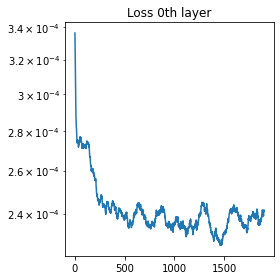

In [56]:
plot_losses(losses, offset = 0)

In [57]:
x1, x2, r = peak_one(val_dataset)
Q_models[0](torch.tensor(x1, dtype = torch.float32))

tensor([0.7652, 0.6532, 0.8453, 0.7181, 0.7771, 0.7320, 0.6219, 0.8148, 0.6709,
        0.7343, 0.6857, 0.5803, 0.7716, 0.6367, 0.6945, 0.6867, 0.5585, 0.7248,
        0.6205, 0.6901, 0.6248, 0.5490, 0.7027, 0.5745, 0.6253, 0.5670, 0.5159,
        0.6647, 0.5556, 0.5709, 0.5573, 0.4929, 0.5996, 0.5239, 0.5357, 0.5310],
       grad_fn=<SigmoidBackward0>)

In [58]:
r

array([0.64, 0.56, 0.76, 0.56, 0.8 , 0.76, 0.52, 0.76, 0.56, 0.8 , 0.68,
       0.52, 0.76, 0.52, 0.8 , 0.8 , 0.48, 0.72, 0.52, 1.  , 0.72, 0.48,
       0.92, 0.48, 0.84, 0.56, 0.48, 0.6 , 0.48, 0.56, 0.52, 0.44, 0.56,
       0.48, 0.56, 0.52])

In [59]:
save(Q_models[0], "models/one_layer/l0.pth")

# Evalution sur le jeu de test

In [60]:
test_dataset = pd.concat([pd.read_csv(f"data/slice{k}.csv", index_col = 0) for k in range (12, 14)])
Q_models = [torch.load("models/one_layer/l0.pth", weights_only=False)]
results = assess_models(Q_models, test_dataset)
results

c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:54: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  state = torch.tensor(hand, dtype=torch.float32) if i == 0 else torch.tensor(
c:\Users\Chardin Pierre\OneDrive - CentraleSupelec\Bureau\CS\3a\DL\brige\RL-for-bridge-bidding\learning_tools.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return scores[last_contract], last_layer


array([0.85465])

In [61]:
results*25

array([21.36625])